In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

c:\Users\Felipe Novais\.conda\envs\data_jobs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Plot 1: simple box plot

In [2]:
# further data filtering
df_da = df.loc[
    (df["job_country"] == "United States") & (df["job_title_short"] == "Data Analyst") & (df["salary_year_avg"].notna()),
    "salary_year_avg"
].reset_index(drop=True).copy()

C:\Users\Felipe Novais\AppData\Local\Temp\ipykernel_19952\1894617004.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False, medianprops=dict(color="red", linewidth=1.5))


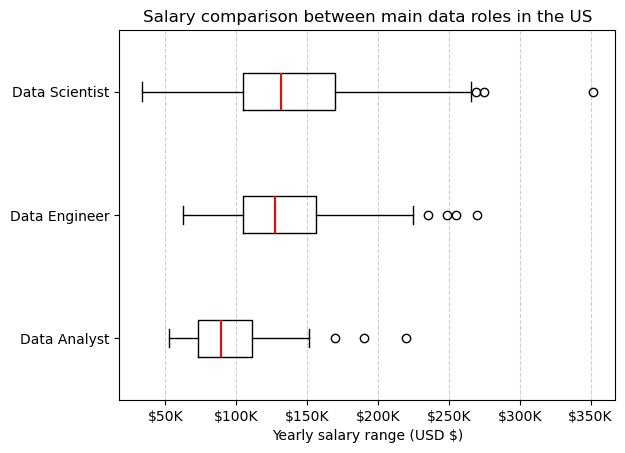

In [36]:
# plotting
job_titles = ["Data Analyst", "Data Engineer", "Data Scientist"]

df_us = df.loc[
    (df["job_location"] == "United States") & (df["salary_year_avg"].notna()) & (df["job_title_short"].isin(job_titles)),
    ["job_title_short", "salary_year_avg"]
].reset_index(drop=True).copy()

job_list = [df_us.loc[df_us["job_title_short"] == job, "salary_year_avg"] for job in job_titles]

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x / 1000)}K"))

plt.boxplot(job_list, labels=job_titles, vert=False, medianprops=dict(color="red", linewidth=1.5))
plt.title("Salary comparison between main data roles in the US")
plt.grid(True, linestyle="--", alpha=0.6)
plt.grid(False, axis="y")
plt.xlabel("Yearly salary range (USD $)")
plt.show()

## Plot 2: Histogram vs Box Plot

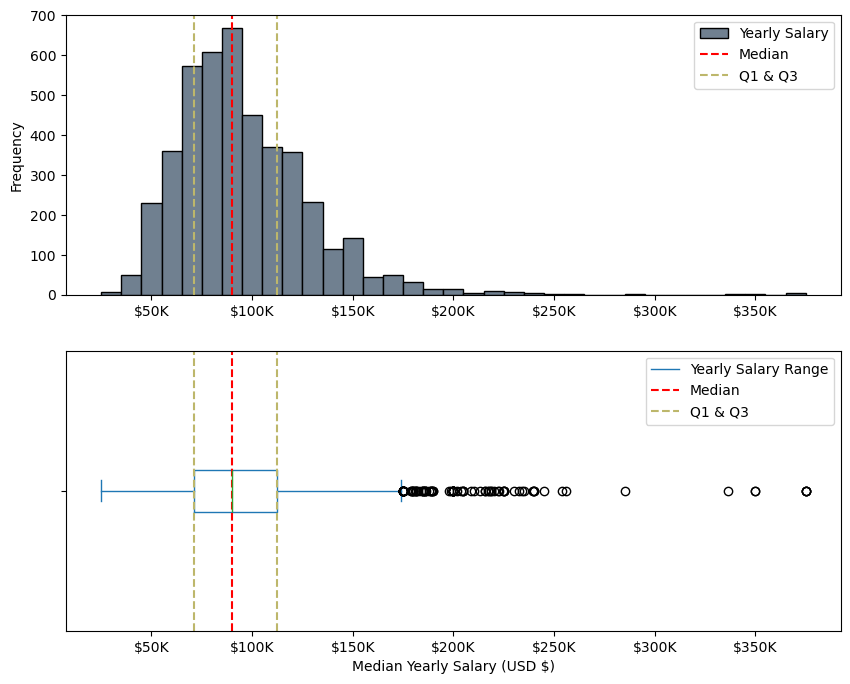

In [4]:
# create plots
fig, ax = plt.subplots(nrows=2, figsize=(10, 8))
median_salary = df_da.median()
q1 = df_da.quantile(0.25)
q3 = df_da.quantile(0.75)

df_da.plot(
    kind="hist",
    ax=ax[0],
    color="slategrey",
    bins=35,
    edgecolor="black"
)
df_da.plot(kind="box", ax=ax[1], vert=False)

# format histogram
ax[0].axvline(median_salary, color="red", linestyle="--")
ax[0].axvline(q1, color="darkkhaki", linestyle="--")
ax[0].axvline(q3, color="darkkhaki", linestyle="--")
ax[0].legend(["Yearly Salary", "Median", "Q1 & Q3"])
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x / 1000)}K"))

# format box plot
ax[1].set_yticklabels("")
ax[1].axvline(median_salary, color="red", linestyle="--")
ax[1].axvline(q1, color="darkkhaki", linestyle="--")
ax[1].axvline(q3, color="darkkhaki", linestyle="--")
ax[1].legend(["Yearly Salary Range", "Median", "Q1 & Q3"])
ax[1].set_xlabel("Median Yearly Salary (USD $)")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x / 1000)}K"))

plt.show()